# TÂCHE 2 : Production et adaptation du notebook brainbeats_binary_classifier.ipynb

Ma deuxième tâche serait de produire le notebook du classificateur binaire brainbeats_binary_classifier en utilisant les données pré-traités trouvées sur Zenodo.

**Voici les sous-tâches nécessaires:**

- Création et exécution complète d'un notebook original
- Création d'un environnement virtuel
- Adaptation du notebook au jeu de données pré-traités
- Ajout de commentaires explicatifs

**Sous-tâche si j'ai les capacité computationnelles:**

- Trouver et tester un autre type de classificateur binaire
- Création d'une visualisation pour comparer les différents classificateurs utilisés

### Étape 1:  
Importer les modules nécessaires pour la tâche

In [1]:
import numpy as np
from scipy.io import loadmat
import os
import urllib.request

from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


### Étape 2:  Téléchargement des données si ce n'est pas déjà fait. 
- Les **données IRMf (.npy)** contiennent l'activité cérébrale mesurée voxel par voxel pendant que les participants écoutaient des extraits musicaux. Cependant, même si on peut distinguer l'activité cérébrale entre chaque extrait, il est impossible de déterminer le genre musical uniquement à partir de ces données.

- Les **fichiers de labels (.mat)** contiennent le genre musical associé à chaque extrait. On doit extraire ces labels et les associer aux données IRMf pour pouvoir entraîner notre modèle.


In [2]:
# Téléchargeons les données! Elles sont disponibles sur Zenodo
Zenodo_Files = {
    'sub-005_Resp_Training.npy': 'https://zenodo.org/records/8275363/files/sub-005_Resp_Training.npy?download=1',
    'sub-005_Resp_Test_Mean.npy': 'https://zenodo.org/records/8275363/files/sub-005_Resp_Test_Mean.npy?download=1',
    'AcrossGenre_Order_Trn.mat':  'https://zenodo.org/records/8275363/files/AcrossGenre_Order_Trn.mat?download=1',
    'AcrossGenre_Order_Test.mat': 'https://zenodo.org/records/8275363/files/AcrossGenre_Order_Test.mat?download=1',
}

def download_data(data_path='./data'):
    """Télécharge les données du sujet 005 depuis Zenodo si elles ne sont pas déjà présentes."""
    os.makedirs(data_path, exist_ok=True)
    for filename, url in Zenodo_Files.items():
        dest = os.path.join(data_path, filename)
        if os.path.exists(dest):
            print(f"Déjà présent, on passe : {filename}")
        else:
            print(f"Téléchargement de {filename} ...")
            urllib.request.urlretrieve(url, dest)
            print(f"  Terminé.")

# --- CONFIGURATION ---
data_path = '../data'
sub = '005'

# --- Téléchargement si nécessaire ---
download_data(data_path)

# Chargement des données

# --- Étape 1 : Chargement des fichiers IRMf (.npy) ---
# mmap_mode='r' évite de charger tout le dataset en RAM
X_train = np.load(f'{data_path}/sub-{sub}_Resp_Training.npy', mmap_mode='r')
X_test  = np.load(f'{data_path}/sub-{sub}_Resp_Test_Mean.npy', mmap_mode='r')

# --- Étape 2 : Transposition → forme (points de temps, voxels) ---
# Chaque ligne = un point de temps, chaque colonne = un voxel
X_train = X_train.T
X_test  = X_test.T

# --- Étape 3 : Chargement des fichiers de labels (.mat) ---
training_labels = loadmat(f'{data_path}/AcrossGenre_Order_Trn.mat')
test_labels     = loadmat(f'{data_path}/AcrossGenre_Order_Test.mat')

# --- Étape 4 : Vérification des dimensions ---
print("Dimensions X_train :", X_train.shape)
print("Dimensions X_test :", X_test.shape)
print("Dimensions labels d'entraînement :", training_labels['across_genre_rn_trn'].shape)

# Extraction de la clé valide dans les labels de test (ignore les métadonnées)
key = [k for k in test_labels.keys() if not k.startswith('_')][0]
print("Clé labels de test :", key)
print("Dimensions labels de test :", test_labels[key].shape)

Déjà présent, on passe : sub-005_Resp_Training.npy
Déjà présent, on passe : sub-005_Resp_Test_Mean.npy
Déjà présent, on passe : AcrossGenre_Order_Trn.mat
Déjà présent, on passe : AcrossGenre_Order_Test.mat
Dimensions X_train : (4800, 53421)
Dimensions X_test : (600, 53421)
Dimensions labels d'entraînement : (12, 4, 10)
Clé labels de test : across_genre_rn_test
Dimensions labels de test : (6, 4, 10)


### Étape 3 : Construction des labels et filtrage Pop vs Classical
Les données contiennent 10 genres. Pour la classification binaire, on doit isoler uniquement les extraits de Pop (label 8) et Classical (label 2), puis réassigner leurs labels à 0 et 1 pour que le classificateur puisse les distinguer.

In [4]:
# --- Étape 2 : Explorer les labels ---
# Les labels sont des entiers qui encodent le genre musical de chaque extrait.
# On extrait les tableaux de labels et on regarde les valeurs uniques
# pour identifier quel entier correspond à quel genre.
y_train = training_labels['across_genre_rn_trn'].flatten()
y_test  = test_labels[key].flatten()

print("Labels uniques (entraînement):", np.unique(y_train))
print("Labels uniques (test):", np.unique(y_test))
print("Nombre d'extraits par label (entraînement):", {l: np.sum(y_train == l) for l in np.unique(y_train)})

Labels uniques (entraînement): [ 1  2  3  4  5  6  7  8  9 10]
Labels uniques (test): [ 1  2  3  4  5  6  7  8  9 10]
Nombre d'extraits par label (entraînement): {np.uint8(1): np.int64(48), np.uint8(2): np.int64(48), np.uint8(3): np.int64(48), np.uint8(4): np.int64(48), np.uint8(5): np.int64(48), np.uint8(6): np.int64(48), np.uint8(7): np.int64(48), np.uint8(8): np.int64(48), np.uint8(9): np.int64(48), np.uint8(10): np.int64(48)}


In [5]:
# --- Mapping des genres ---
# 1=blues, 2=classical, 3=country, 4=disco, 5=hiphop,
# 6=jazz, 7=metal, 8=pop, 9=reggae, 10=rock
GENRE_CLASSICAL = 2
GENRE_POP       = 8

# --- Étape 1 : Moyenne temporelle ---
# Chaque clip contient 10 TRs → on moyenne pour obtenir 1 vecteur par clip
n_tr     = 10
n_voxels = X_train.shape[1]

X_train_avg = X_train.reshape(480, n_tr, n_voxels).mean(axis=1)  # (480, voxels)
X_test_avg  = X_test.reshape(60, n_tr, n_voxels).mean(axis=1)    # (60, voxels)

# --- Étape 2 : Construction des labels ---
y_train_all = training_labels['across_genre_rn_trn'].reshape(-1)

key = [k for k in test_labels.keys() if not k.startswith('_')][0]
y_test_all = test_labels[key][:, 0, :].flatten()

# --- Étape 3 : Filtrage Pop et Classical ---
train_mask = np.isin(y_train_all, [GENRE_CLASSICAL, GENRE_POP])
test_mask  = np.isin(y_test_all,  [GENRE_CLASSICAL, GENRE_POP])

X_train_bin = X_train_avg[train_mask]
X_test_bin  = X_test_avg[test_mask]
y_train_bin = y_train_all[train_mask]
y_test_bin  = y_test_all[test_mask]

print("Taille entraînement après filtrage :", X_train_bin.shape)
print("Taille test après filtrage :", X_test_bin.shape)
print("Distribution entraînement :", {2: np.sum(y_train_bin == 2), 8: np.sum(y_train_bin == 8)})
print("Distribution test :", {2: np.sum(y_test_bin == 2), 8: np.sum(y_test_bin == 8)})

Taille entraînement après filtrage : (96, 53421)
Taille test après filtrage : (12, 53421)
Distribution entraînement : {2: np.int64(48), 8: np.int64(48)}
Distribution test : {2: np.int64(6), 8: np.int64(6)}


### Étape 4 : Exploration des hyperparamètres avec GridSearchCV
Le GridSearchCV va tester toutes les combinaisons possibles d'hyperparamètres et trouver automatiquement la meilleure. C'est ce qu'on appelle la sélection de modèles.

{'linearsvc__C': 10, 'pca__n_components': 50}
0.665
1.0


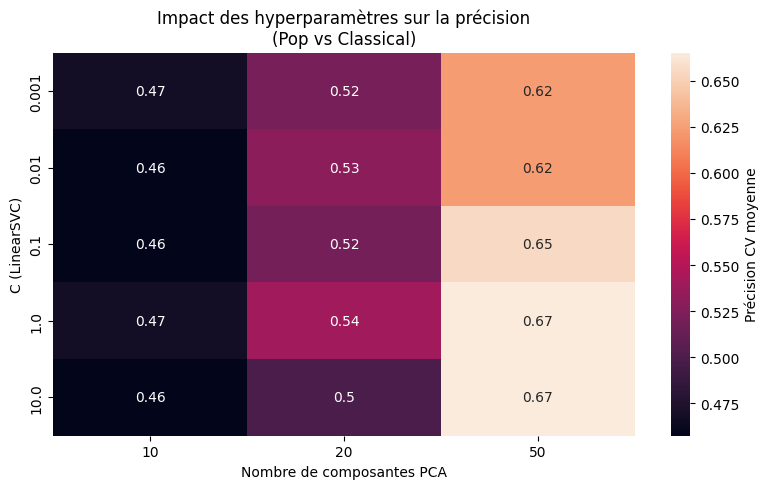

In [6]:
# Pipeline complet
pipeline = Pipeline([('scaler', StandardScaler()),('pca', PCA()), ('linearsvc', LinearSVC(max_iter=10000))])

# Grille d’hyperparamètres à tester
param_grid = {'pca__n_components': [10, 20, 50], 'linearsvc__C': [0.001, 0.01, 0.1, 1, 10]}

# Validation croisée stratifiée
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search : teste toutes les combinaisons d’hyperparamètres avec CV
grid_search = GridSearchCV(pipeline, param_grid, cv=strat_kfold)

# Entraînement sur les données d'entraînement
grid_search.fit(X_train_bin, y_train_bin)

# Affichage des meilleurs hyperparamètres trouvés
print(grid_search.best_params_)

# Score moyen en validation croisée pour la meilleure configuration
print(round(grid_search.best_score_, 3))

# Évaluation finale sur le jeu de test (jamais vu pendant l’entraînement)
print(round(grid_search.score(X_test_bin, y_test_bin), 3)) 

# --- Visualisation : heatmap des scores CV ---
# Conversion des résultats du grid search en DataFrame
results = pd.DataFrame(grid_search.cv_results_)
scores = results.pivot_table(
    index='param_linearsvc__C',
    columns='param_pca__n_components',
    values='mean_test_score'
)

# Création de la heatmap des performances
plt.figure(figsize=(8, 5))
sns.heatmap(scores, annot=True, cbar_kws={'label': 'Précision CV moyenne'})
plt.title('Impact des hyperparamètres sur la précision\n(Pop vs Classical)')
plt.xlabel('Nombre de composantes PCA')
plt.ylabel('C (LinearSVC)')
plt.tight_layout()
plt.show()

### Étape 5:   Tester sur plusieurs différents types de modèles   
Jusqu'ici on a utilisé un SVM. Pour savoir si ce choix est optimal, on compare ses performances avec deux autres classificateurs courants :

- **un RandomForest** :ensemble de plusieurs arbres de décision qui votent ensemble pour prédire la classe.

- **KNN** (K-Nearest Neighbors) : prédit la classe d'un clip en regardant les `k` clips d'entraînement les plus similaires.


In [7]:
from sklearn.ensemble import RandomForestClassifier

# --- Pipeline Random Forest ---
pipeline_randf = Pipeline([('scaler', StandardScaler()),('pca', PCA()),('rf', RandomForestClassifier(random_state=42))])

param_grid_randf = {'pca__n_components': [10, 20, 50],'rf__n_estimators':  [50, 100, 200]}

grid_search_randf = GridSearchCV(pipeline_randf, param_grid_randf, cv=strat_kfold)
grid_search_randf.fit(X_train_bin, y_train_bin)

print("Meilleurs hyperparamètres :", grid_search_randf.best_params_)
print("Meilleur score CV :", round(grid_search_randf.best_score_, 3))
print("Précision sur le test :", round(grid_search_randf.score(X_test_bin, y_test_bin), 3))

Meilleurs hyperparamètres : {'pca__n_components': 50, 'rf__n_estimators': 200}
Meilleur score CV : 0.593
Précision sur le test : 1.0


In [8]:
# Maintenant essayons un KNN
from sklearn.neighbors import KNeighborsClassifier

# --- Pipeline KNN ---
pipeline_KNN = Pipeline([('scaler', StandardScaler()),('pca', PCA()),('knn', KNeighborsClassifier())])

param_grid_KNN = {
    'pca__n_components': [10, 20, 50],
    'knn__n_neighbors':  [3, 5, 7, 11],
}

grid_search_kNN = GridSearchCV(pipeline_KNN, param_grid_KNN, cv=strat_kfold, scoring='accuracy')
grid_search_kNN.fit(X_train_bin, y_train_bin)

print("Meilleurs hyperparamètres :", grid_search_kNN.best_params_)
print("Meilleur score CV :", round(grid_search_kNN.best_score_, 3))
print("Précision sur le test :", round(grid_search_kNN.score(X_test_bin, y_test_bin), 3))

Meilleurs hyperparamètres : {'knn__n_neighbors': 7, 'pca__n_components': 10}
Meilleur score CV : 0.521
Précision sur le test : 0.5


### Étape 6 : Comparer les 3 modèles

Maintenant qu'on a entraîné et optimisé les trois modèles, on peut les comparer directement. Pour chaque modèle, on affiche deux scores :

- **Score CV** : la précision moyenne obtenue en validation croisée sur les données d'entraînement — c'est une estimation de la performance du modèle en général
- **Score Test** : la précision obtenue sur les données de test que le modèle n'a jamais vues — c'est la vraie mesure de généralisation

Un bon modèle devrait avoir des scores CV et Test proches l'un de l'autre. Un écart important entre les deux peut indiquer de l'overfitting.

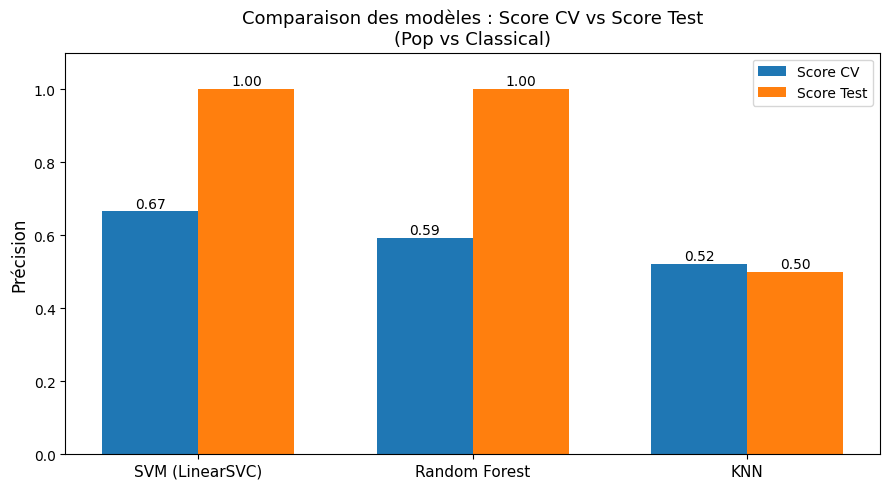

In [9]:
# --- Graphique comparatif des 3 modèles ---
modeles = ['SVM (LinearSVC)', 'Random Forest', 'KNN']

scores_cv = [
    grid_search.best_score_,
    grid_search_randf.best_score_,
    grid_search_kNN.best_score_
]

scores_test = [
    grid_search.score(X_test_bin, y_test_bin),
    grid_search_randf.score(X_test_bin, y_test_bin),
    grid_search_kNN.score(X_test_bin, y_test_bin)
]

x = np.arange(len(modeles))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_cv   = ax.bar(x - width/2, scores_cv,   width, label='Score CV')
bars_test = ax.bar(x + width/2, scores_test, width, label='Score Test')

# Ajouter les valeurs sur les barres
for bar in bars_cv:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center')

for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center')

ax.set_xticks(x)
ax.set_xticklabels(modeles, fontsize=11)
ax.set_ylabel('Précision', fontsize=12)
ax.set_title('Comparaison des modèles : Score CV vs Score Test\n(Pop vs Classical)', fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

### Étape 7 : Fonction de classification binaire personnalisée

Jusqu'ici on a uniquement comparé Pop et Classical. Cette fonction permet à l'utilisateur de choisir n'importe quelle paire de genres et d'entraîner un SVM binaire sur celle-ci. C'est une façon d'explorer quels genres sont les plus faciles ou les plus difficiles à distinguer pour le cerveau.

In [10]:
def binary_classifier(genre_1, genre_2, X_train_avg, X_test_avg, y_train_all, y_test_all, n_components=50, C=0.1):
    # Mapping pour afficher les noms des genres
    genre_names = {1: 'blues', 2: 'classical', 3: 'country', 4: 'disco',5: 'hiphop', 6: 'jazz', 7: 'metal', 8: 'pop', 9: 'reggae', 10: 'rock'}

    # --- Filtrage des deux genres ---
    train_mask = np.isin(y_train_all, [genre_1, genre_2])
    test_mask  = np.isin(y_test_all,  [genre_1, genre_2])

    X_tr = X_train_avg[train_mask]
    X_te = X_test_avg[test_mask]
    y_tr = y_train_all[train_mask]
    y_te = y_test_all[test_mask]

    # --- Pipeline ---
    pipeline = Pipeline([('scaler', StandardScaler()),('pca', PCA(n_components=n_components)),('linearsvc', LinearSVC())])

    # --- Validation croisée stratifiée ---
    strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_tr, y_tr, cv=strat_kfold)

    # --- Entraînement final et évaluation ---
    pipeline.fit(X_tr, y_tr)
    test_acc = pipeline.score(X_te, y_te)

    print(f"Classification : {genre_names[genre_1]} vs {genre_names[genre_2]}")
    print(f"  Précision CV  : {cv_scores.mean().round(3)}")
    print(f"  Précision test: {round(test_acc, 3)}")

    y_pred = pipeline.predict(X_te)
    # --- matrice de confusion ---
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels= [genre_names[genre_1],genre_names[genre_2]])
    
    disp.plot(cmap = 'Blues')
    plt.title(f"Matrice de confusion : {genre_names[genre_1]} vs {genre_names[genre_2]}")
    plt.show()

    return cv_scores.mean(), test_acc


Classification : classical vs country
  Précision CV  : 0.593
  Précision test: 0.917


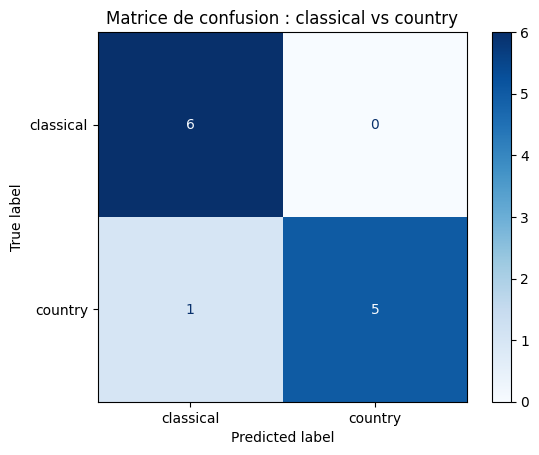

(np.float64(0.5926315789473684), 0.9166666666666666)

In [11]:
# --- Exemple d'utilisation ---
binary_classifier(2, 3, X_train_avg, X_test_avg, y_train_all, y_test_all)

### Déclaration d'utilisation de l'intelligence artificielle

Dans le cadre de cette tâche, l'intelligence artificielle (IA) a été utilisée à des fins de débogage et d'assistance au développement. Plus précisément, des outils d'IA générative (tels que Claude ou ChatGPT) ont été consultés pour identifier et corriger des erreurs dans le code Python et pour interpréter des messages d'erreur.

BIBLIOGRAPHIE

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html

https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

https://seaborn.pydata.org/generated/seaborn.heatmap.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

